In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('./PerturbVAE')

from model import *
from utils import *
from dataset import *
from PerturbVAE.trainer import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
data = sc.read_h5ad('/home/mingxuanzhang/PerturbVAE/perturb_filtered_gbm_crispri_crop (3).h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [4]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

In [5]:
dataset = PerturbMatchingDataset(data)

In [6]:
sampler = MultiClassBatchSampler(
    labels                = dataset.P_indices,
    n_classes_per_batch   = 10,            # e.g. 4 classes per batch
    shuffle_within_class  = True,         # optional
    drop_last             = False          # drop incomplete last group
)
# dataloader = DataLoader(dataset,
#                     batch_sampler=sampler)

dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=0)


In [7]:
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [8]:
x = torch.tensor(data.X.toarray(), dtype=torch.float32)
cov = x.T @ x / (x.shape[0] - 1)
cov = cov + torch.eye(cov.shape[0]) * 1e-6  # Add small value to diagonal for numerical stability

In [9]:
import seaborn as sns

In [10]:
def _normalize(cov, eps=1e-12):
    std = np.sqrt(np.diag(cov))
    std[std < eps] = np.inf
    denom = np.outer(std, std)
    corr = cov / denom
    np.fill_diagonal(corr, 1.0)        
    return corr

In [11]:
corr = _normalize(cov.numpy())
corr.shape

(2218, 2218)

In [12]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform

def corr_to_modules(corr: np.ndarray,
                    n_clusters: int | None = None,
                    linkage_method: str = "average",
                    balance: bool = False) -> dict[int, list[int]]:
    dist_vec = squareform(1.0 - np.abs(corr), checks=False)
    Z = linkage(dist_vec, method=linkage_method)
    if balance and n_clusters is not None:
        # dendrogram leaf order keeps similar genes adjacent
        order = leaves_list(Z)
        N = len(order)

        # compute target block sizes: first `n_big` blocks get +1 gene
        base = N // n_clusters
        n_big = N % n_clusters          # #clusters that will be one gene larger

        modules = {}
        idx = 0
        for m in range(1, n_clusters + 1):
            size = base + (1 if m <= n_big else 0)
            modules[m] = order[idx: idx + size].tolist()
            idx += size
        return modules


In [13]:
gene_module_dict = corr_to_modules(corr, n_clusters=16, linkage_method='average', balance=True)
for k, v in gene_module_dict.items():
    print(f"Module {k}: {len(v)} genes")

Module 1: 139 genes
Module 2: 139 genes
Module 3: 139 genes
Module 4: 139 genes
Module 5: 139 genes
Module 6: 139 genes
Module 7: 139 genes
Module 8: 139 genes
Module 9: 139 genes
Module 10: 139 genes
Module 11: 138 genes
Module 12: 138 genes
Module 13: 138 genes
Module 14: 138 genes
Module 15: 138 genes
Module 16: 138 genes


In [26]:
input_dim = data.shape[-1] 
latent_dim = len(gene_module_dict.keys())
vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100, module_dict=gene_module_dict,
                 center_coeff_init=1, use_gene_modules=True)
vae = vae.to(vae.device)

In [ ]:
pyro.clear_param_store()
trainer = VAETrainer(
    vae,
    dataloader,
    lr=1e-3,
    num_epochs=200,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=1.0,
    tau_end=0.1, 
    gate_start=50,
)

trainer.fit()

Training VAE on cuda …


Epochs:   0%|                                                                                                 …

Epoch 1:   0%|                                                                                                …

torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size([2218]) 50
torch.Size

KeyboardInterrupt: 

In [48]:
import pyro.poutine as poutine
model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))            

X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
X_ntc = []
for i in C:
    rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
    X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
X_ntc = torch.stack(X_ntc, dim=0)
                    
trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

cpu


In [49]:
cls_logits = trace_model.nodes["cls_logits"]["value"]
val_correct = (cls_logits.argmax(dim=-1) == P).sum().item()
val_n = P.size(0)
acc = val_correct / val_n
print(f"Validation accuracy: {acc:.4f}")

Validation accuracy: 0.9467


In [50]:
z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X_p.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


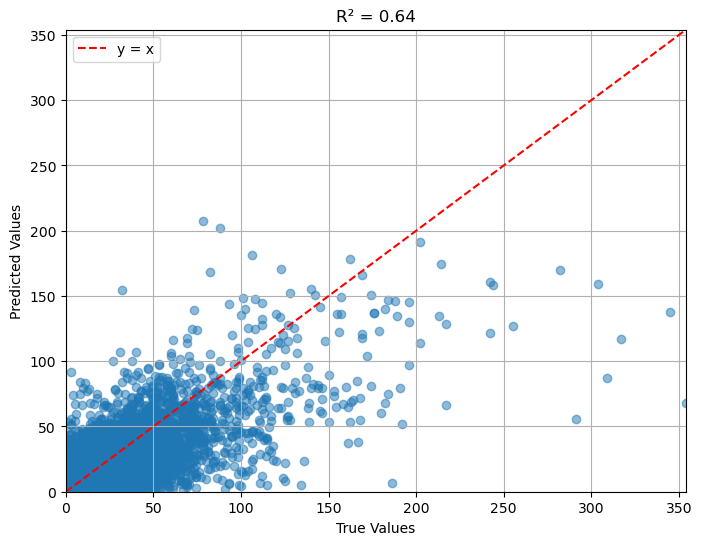

In [51]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(X_p.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, X_p.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = X_p[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


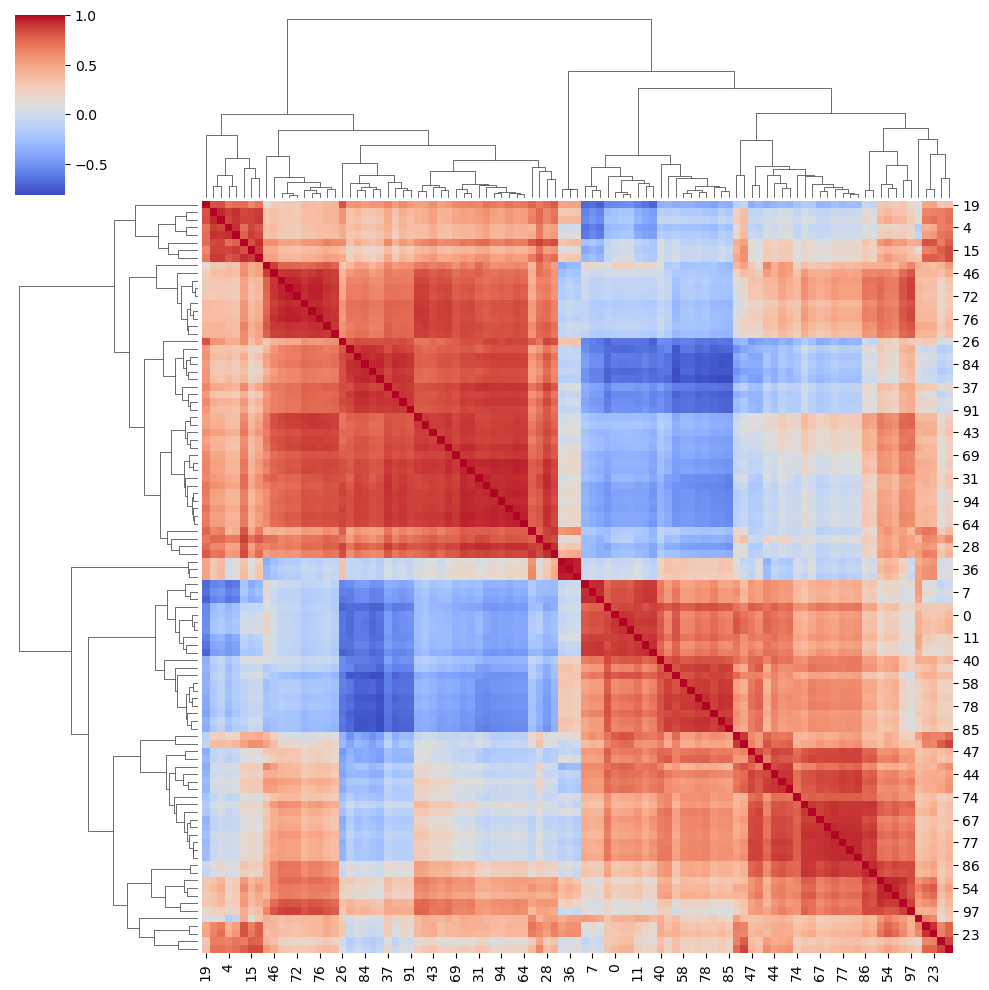

In [52]:
import torch, pyro
import matplotlib.pyplot as plt
import seaborn as sns                   

with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)
corr = vae._corr(Sigma_P_posterior).numpy()
sns.clustermap(corr, cmap="coolwarm", annot=False)


In [53]:
z = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

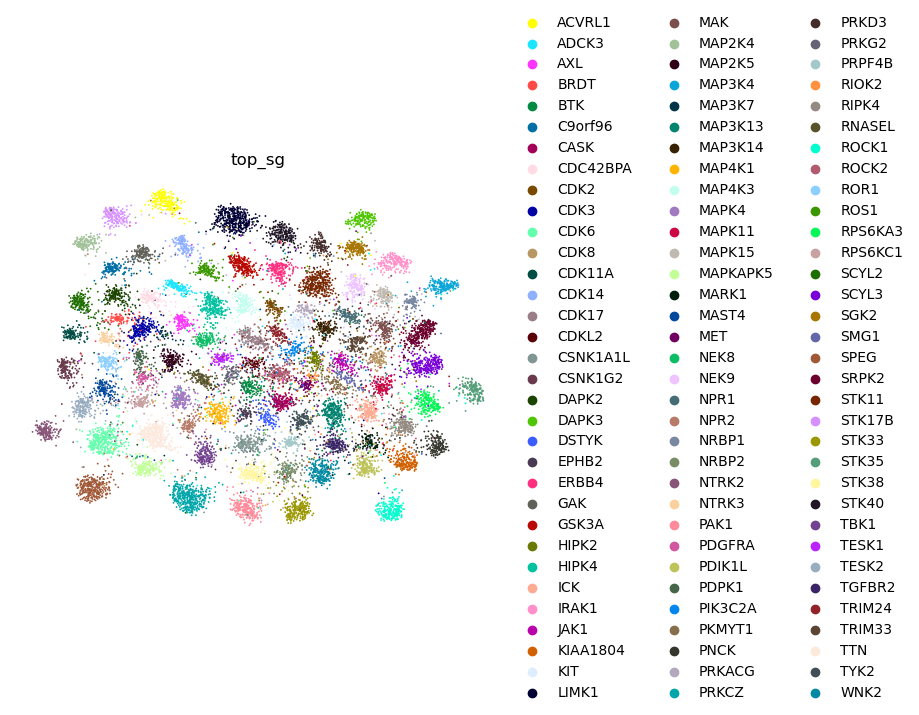

In [54]:
z_data = data[data.obs.top_sg != 'NTC'].copy()
z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, use_rep='z', n_neighbors=15)
sc.tl.umap(z_data)
sc.pl.umap(z_data, color=['top_sg'], frameon=False, show=True)

In [55]:
num_p = vae.perturbs
d = vae.latent_dim
Sigma_P_posterior = vae._corr(Sigma_P_posterior)

z_bar = torch.zeros(num_p, d)
counts = torch.zeros(num_p)
for p in range(num_p):
    mask = (P == p)
    if mask.any():
        z_bar[p] = z[mask].mean(0)
        counts[p] = mask.sum()

# (Optional) skip perturbations with very few cells
valid = counts > 2
Sigma_z = torch.corrcoef(z_bar[valid])          # (P_valid × P_valid)
Sigma_P_posterior = Sigma_P_posterior[valid][:, valid]              # align shapes

In [56]:
def flat_triu(M):
    idx = torch.triu_indices(M.size(0), M.size(1), offset=1)
    return M[idx[0], idx[1]]

rho_flat  = flat_triu(Sigma_P_posterior).numpy()
z_flat    = flat_triu(Sigma_z.detach()).numpy()

from scipy.stats import spearmanr, pearsonr
r_s, p_s = spearmanr(rho_flat, z_flat)
r_p, p_p = pearsonr(rho_flat, z_flat)

print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.1e})")
print(f" Pearson  r = {r_p:.3f}  (p = {p_p:.1e})")

Spearman ρ = 0.534  (p = 0.0e+00)
 Pearson  r = 0.555  (p = 0.0e+00)


In [57]:
sigma_w = vae.E_pert_sim(min_conf=0.2).detach().cpu().numpy()

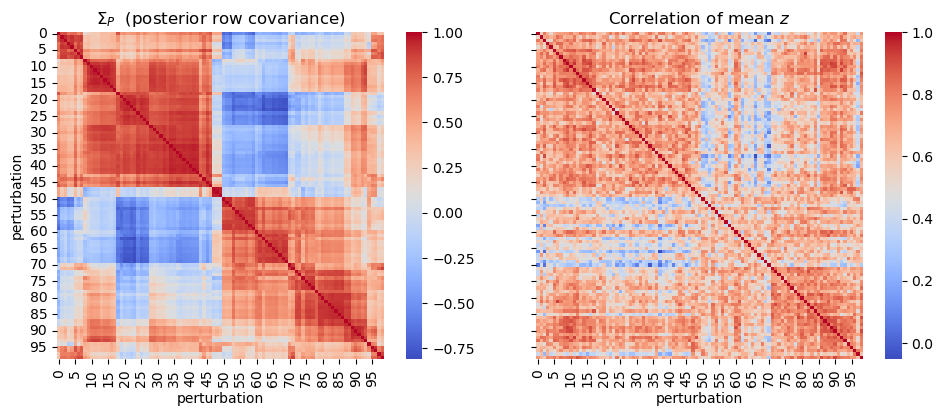

In [58]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib import gridspec

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list


link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
order = leaves_list(link)              # permutation indices, shape (P,)

# ── 2.  apply the same permutation to both matrices ─────────────────
SigmaP_ord = Sigma_P_posterior[order][:, order]

# Sigma_z : correlation between perturbation-mean z’s  (P × P)
Sigmaz_ord = Sigma_z.detach().cpu().numpy()[order][:, order]

# Sigma w:
Sigmaw_ord = sigma_w[order][:, order]

# ── 3.  plot side-by-side heat-maps ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title(r"$\Sigma_P$  (posterior row covariance)")
axes[0].set_xlabel("perturbation"); axes[0].set_ylabel("perturbation")

sns.heatmap(Sigmaz_ord, cmap="coolwarm", square=True, ax=axes[1])
axes[1].set_title("Correlation of mean $z$")
axes[1].set_xlabel("perturbation")


plt.tight_layout()
plt.show()

In [59]:
z_data

AnnData object with n_obs × n_vars = 17445 × 2218
    obs: 'P7', 'P5', 'sample', 'n.umi', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'log10.umi', 'percent_mito', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene_id', 'batch', 'library_size'
    var: 'features'
    uns: 'neighbors', 'umap', 'top_sg_colors'
    obsm: 'z', 'X_umap'
    obsp: 'distances', 'connectivities'

In [60]:
P

tensor([24, 10,  5,  ..., 25,  3, 29])

In [61]:
n_classes = P.unique().shape[0]
centroids = torch.stack([z[P==k].mean(0) for k in range(n_classes)])
inter = centroids.var(0).sum()
intra = (z - centroids[P]).var(0).sum()
print("inter / intra variance :", inter.item() / intra.item())


inter / intra variance : 1.7343540084935132


In [62]:
z_data.obsm['z'].shape

(17445, 16)

In [ ]:
z0_data = data.copy()
z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='z0', n_neighbors=15)
sc.tl.umap(z0_data)

In [ ]:
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [65]:
pi = trace.nodes["pi"]['value']
pi

tensor([[0.6534, 0.3305, 0.3408,  ..., 0.6514, 0.6514, 0.5610],
        [0.5535, 0.2988, 0.6094,  ..., 0.6016, 0.5990, 0.6104],
        [0.6023, 0.4126, 0.4293,  ..., 0.6176, 0.6622, 0.4107],
        ...,
        [0.6676, 0.5080, 0.6633,  ..., 0.5859, 0.6489, 0.6614],
        [0.6200, 0.4147, 0.3598,  ..., 0.6682, 0.6362, 0.5840],
        [0.6691, 0.6158, 0.5352,  ..., 0.4515, 0.6558, 0.5684]],
       grad_fn=<ExpandBackward0>)

(array([  4.,  25.,  32.,  34.,  39.,  34.,  38.,  30.,  42.,  23.,  32.,
         34.,  43.,  29.,  48.,  37.,  52.,  68.,  65.,  55.,  82.,  89.,
         81.,  84., 116., 103., 141.,  98.,  25.,   1.]),
 array([0.24207912, 0.2573657 , 0.27265227, 0.28793883, 0.3032254 ,
        0.31851196, 0.33379853, 0.34908509, 0.36437166, 0.37965822,
        0.39494479, 0.41023135, 0.42551792, 0.44080451, 0.45609108,
        0.47137764, 0.48666421, 0.50195074, 0.51723731, 0.53252393,
        0.54781049, 0.56309706, 0.57838362, 0.59367019, 0.60895675,
        0.62424332, 0.63952988, 0.65481645, 0.67010301, 0.68538958,
        0.70067614]),
 <BarContainer object of 30 artists>)

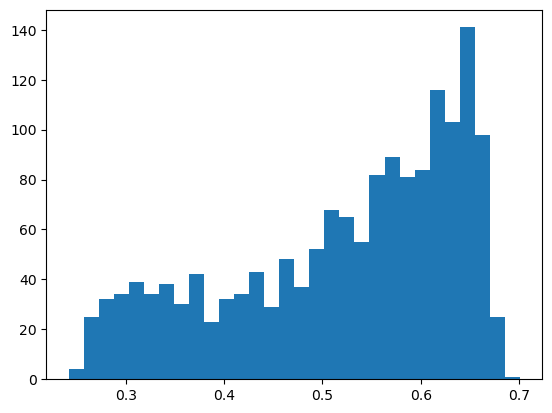

In [66]:
plt.hist(pi.detach().cpu().numpy().flatten(), bins=30)

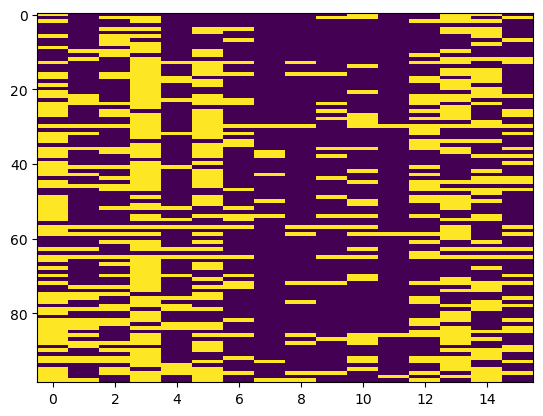

In [68]:
pi_bin = (pi > 0.6).float()
plt.imshow(pi_bin.cpu().numpy(), aspect='auto')

In [69]:
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, metric='euclidean', random_state=0)
Z2 = reducer.fit_transform(z.detach().cpu().numpy())

/home/mingxuanzhang/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Exception ignored in: Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/home/mingxuanzhang/anaconda3/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
<function _ConnectionBase.__del__ at 0x7feb74f15300>
Traceback (most recent call last):
  File "/home/mingxuanzhang/anaconda3/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    reader_close()
  File "/home/mingxuanzhang/anaconda3/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/mingxuanzhang/anaconda3/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
    self._close()
  File "/home/mingxuanzhang/anaconda3/lib/python3.12/multiprocessing/connection.py", line 377, in

In [74]:
import numpy as np
centroids = np.zeros((vae.perturbs, z.shape[1]))
for a in range(vae.perturbs):
    centroids[a] = z.detach()[P == a].mean(0)
cent2 = reducer.transform(centroids)

In [75]:
from scipy.cluster.hierarchy import linkage, fcluster
C = vae._corr(Sigma_P_posterior).cpu().numpy()
D = 1.0 - C  # distance
Z_link = linkage(D[np.triu_indices_from(D, 1)], method='average')
groups = fcluster(Z_link, t=0.5, criterion='distance')  # tune t

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib as mpl


def _discrete_cmap(n, base_cmap='tab20'):
    """
    Make an n-bin discrete ListedColormap from a continuous or qualitative base cmap.
    For large n (e.g., 100), interpolating a continuous cmap (turbo, viridis, gist_ncar)
    actually yields *more* distinct colors than repeating a short qualitative palette.
    """
    base = plt.cm.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, n))
    return ListedColormap(color_list)


def _scanpy_categorical_palette(n, prefer='default', fallback_cmap='gist_ncar'):
    """
    Return a list of n distinct colors using Scanpy's categorical palettes.
    Parameters
    ----------
    n : int
        Number of categories needed.
    prefer : {'default','zeileis','vega','scanpy','any'}
        Preference heuristic; 'default' tries Scanpy's default_* palettes first.
    fallback_cmap : str
        Matplotlib cmap name to fall back to if scanpy unavailable.
    """
    try:
        import scanpy as sc
    except ImportError:
        # fallback: discrete colormap from matplotlib
        return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)

    pals = []
    # Build candidate palettes in preference order
    if prefer in ('default', 'any'):
        pals.extend([
            sc.pl.palettes.default_20,
            getattr(sc.pl.palettes, 'default_28', []),
            sc.pl.palettes.default_102,   # length 102
        ])
    if prefer in ('zeileis', 'any'):
        # Zeileis palettes are good for many categories
        pals.extend([
            sc.pl.palettes.zeileis_26,
            sc.pl.palettes.zeileis_102,   # length 102
        ])
    if prefer in ('vega', 'scanpy', 'any'):
        # Additional widely used palettes
        pals.extend([
            sc.pl.palettes.vega_20_scanpy,
            sc.pl.palettes.vega_20,       # original vega
        ])

    # deduplicate while preserving order
    seen = set()
    uniq_pals = []
    for pal in pals:
        if pal is None:
            continue
        # convert to tuple so hashable
        tpl = tuple(pal)
        if tpl in seen:
            continue
        seen.add(tpl)
        uniq_pals.append(list(pal))

    # choose the *smallest* palette that still covers n
    chosen = None
    for pal in uniq_pals:
        if len(pal) >= n:
            chosen = pal[:n]
            break

    if chosen is None:
        # no palette long enough; take the longest and extend by cycling
        longest = max(uniq_pals, key=len) if uniq_pals else []
        if not longest:  # still empty? fallback
            return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)
        reps = int(np.ceil(n / len(longest)))
        chosen = (longest * reps)[:n]

    return chosen


def plot_umap_cells_by_cluster_and_pert(
    Z2, P, cent2, groups,
    *,
    cluster_base_cmap=None,
    pert_base_cmap='gist_ncar',
    use_scanpy_palette_for_pert=True,
    use_scanpy_palette_for_groups=False,
    scanpy_palette_prefer='default',
    cell_size=5,
    alpha_cells=0.6,
    centroid_size=80,
    annotate_centroids=False,
    max_cluster_legend=25,
    fig_kw=None,
):
    Z2 = np.asarray(Z2)
    P = np.asarray(P, dtype=int)
    cent2 = np.asarray(cent2)
    groups = np.asarray(groups)

    n_cells = Z2.shape[0]
    n_pert = cent2.shape[0] if cent2 is not None else P.max() + 1

    # ---- cluster mapping ----
    grp_labels, grp_codes = np.unique(groups, return_inverse=True)  # grp_codes: (n_pert,)
    G = len(grp_labels)
    cell_grp = grp_codes[P]  # cluster id per cell

    # choose cluster cmap
    if use_scanpy_palette_for_groups:
        cluster_colors = _scanpy_categorical_palette(G, prefer=scanpy_palette_prefer)
        cluster_cmap = ListedColormap(cluster_colors)
    else:
        if cluster_base_cmap is None:
            if G <= 10:
                cluster_base_cmap = 'tab10'
            elif G <= 20:
                cluster_base_cmap = 'tab20'
            else:
                cluster_base_cmap = 'hsv'
        cluster_cmap = _discrete_cmap(G, base_cmap=cluster_base_cmap)
        cluster_colors = cluster_cmap(np.arange(G))

    # per-perturbation cmap
    if use_scanpy_palette_for_pert:
        pert_colors = _scanpy_categorical_palette(n_pert, prefer=scanpy_palette_prefer,
                                                  fallback_cmap=pert_base_cmap)
        pert_cmap = ListedColormap(pert_colors)
    else:
        pert_cmap = _discrete_cmap(n_pert, base_cmap=pert_base_cmap)

    # ---- figure ----
    if fig_kw is None:
        fig_kw = {}
    fig, axes = plt.subplots(
        1, 2,
        figsize=fig_kw.get('figsize', (12, 5)),
        sharex=True, sharey=True,
        gridspec_kw=fig_kw.get('gridspec_kw', None),
        constrained_layout=fig_kw.get('constrained_layout', False)
    )

    axc, axp = axes

    # ------------------------------------------------------------------
    # Panel 1: Cells colored by cluster
    # ------------------------------------------------------------------
    axc.scatter(
        Z2[:, 0], Z2[:, 1],
        c=cell_grp,
        cmap=cluster_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    axc.set_title("z space, Cells colored by perturbation groups", fontsize=10)

    # Legend (clusters)
    if G <= max_cluster_legend:
        if use_scanpy_palette_for_groups:
            cluster_colors_arr = np.array(cluster_colors)
        else:
            cluster_colors_arr = cluster_cmap(np.arange(G))
        handles = [
            mpatches.Patch(color=cluster_colors_arr[i], label=f"group {grp_labels[i]}")
            for i in range(G)
        ]
        axc.legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            title='Perturbation groups'
        )

    # ------------------------------------------------------------------
    # Panel 2: Cells colored by individual perturbation (Scanpy colors)
    # ------------------------------------------------------------------
    axp.scatter(
        Z2[:, 0], Z2[:, 1],
        c=P,
        cmap=pert_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    if annotate_centroids:
        for a, (x_, y_) in enumerate(cent2):
            axp.text(x_, y_, str(a), ha='center', va='center', fontsize=4, zorder=4)

    axp.set_title("z space, Cells colored by perturbation", fontsize=10)

    # Colorbar for perturbations (compact; index scale 0..n_pert-1)
    stride = max(1, n_pert // 20)  # show at most ~20 ticks
    ticks = np.arange(0, n_pert, stride)
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pert-1), cmap=pert_cmap),
        ax=axp,
        fraction=0.046,
        pad=0.04,
    )
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticks.astype(str))
    cbar.set_label("Perturbation ID")

    # ------------------------------------------------------------------
    # Finishing touches
    # ------------------------------------------------------------------
    for ax in axes:
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    return fig, axes


/var/tmp/ipykernel_72760/2393065932.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap(base_cmap)


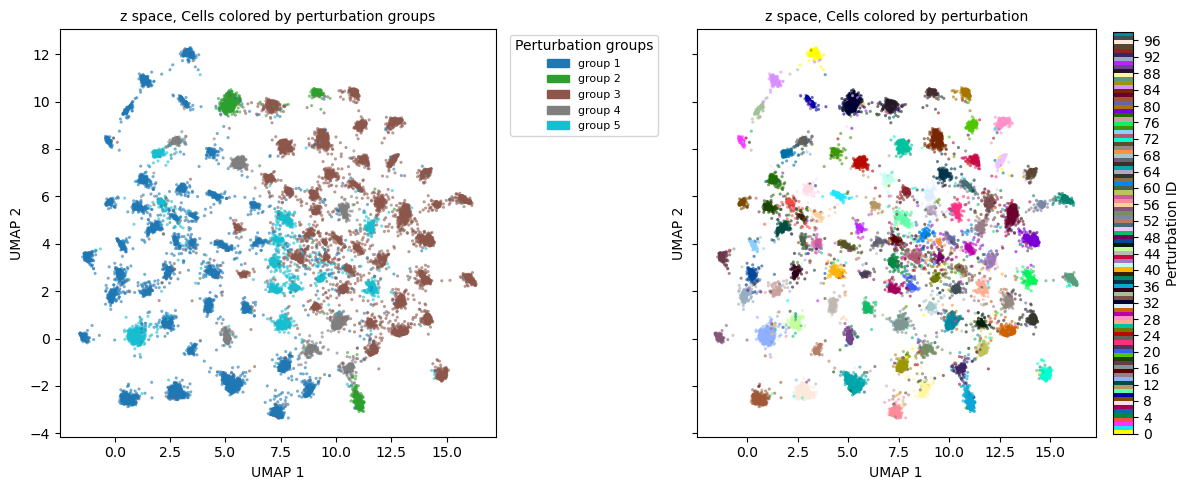

In [77]:
fig, axes = plot_umap_cells_by_cluster_and_pert(
    Z2=Z2,
    P=P,
    cent2=cent2,
    groups=groups,
    pert_base_cmap='nipy_spectral',   # high-contrast for many categories
    annotate_centroids=False,     # set True to label perturbations at centroids
)
plt.show()

# Check W consistency

In [13]:
def _initialize_vaes(dataset, gene_module_dict, n_models=5):
    vaes = []
    for _ in range(n_models):
        # Initialize a new VAE for each model
        input_dim = data.shape[-1] 
        latent_dim = len(gene_module_dict.keys())
        vae = VAE(input_dim, latent_dim, 
                  len(np.unique(dataset.P_indices)),
                  len(np.unique(dataset.C_indices)),
                  100, module_dict=gene_module_dict,
                  center_coeff_init=1e-2)
        vae = vae.to(vae.device)
        vaes.append(vae)
    return vaes

In [14]:
models = _initialize_vaes(dataset, gene_module_dict, n_models=5)

In [15]:
import tqdm

In [16]:
for i in tqdm.tqdm(range(len(models))):
    trainer = VAETrainer(
        models[i],
        dataloader,
        lr=1e-3,
        num_epochs=20,
        init_coeff=models[i].center_coeff_init,                 
        final_coeff=1e-1,                 
        ramp_steps=10000,
        tau_init=1.0,
        tau_end=0.1,
        tau_anneal_steps=10000,
        verbose=False,
        seed=i + 42
    )
    trainer.fit()

  0%|                                                                                                                                 | 0/5 [00:00<?, ?it/s]

Training VAE on cuda …


 20%|████████████████████████                                                                                                | 1/5 [05:20<21:23, 320.85s/it]

Training VAE on cuda …


 40%|████████████████████████████████████████████████                                                                        | 2/5 [10:43<16:05, 321.93s/it]

...

 60%|████████████████████████████████████████████████████████████████████████                                                | 3/5 [16:02<10:41, 320.71s/it]

Training VAE on cuda …


 80%|████████████████████████████████████████████████████████████████████████████████████████████████                        | 4/5 [21:21<05:19, 319.86s/it]

Training VAE on cuda …


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [26:40<00:00, 320.15s/it]


In [17]:
from utils import *

In [18]:
def _model_trace(model, dataset):
    model.eval()
    model.device = torch.device('cpu')
    model = model.to(model.device)
    print(model.device)

    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):        # list() -> safe while mutating
        param_store[name] = value.to(torch.device('cpu'))             # keep grad history

    X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

    trace = poutine.trace(model.guide).get_trace(X, P, C)
    trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X, P, C)
    return trace, trace_model

In [19]:
Ws, Pis = [], []             # graph-level statistics
Zs, Z0s, Rhos = [], [], []    # optional latent diagnostics

for run_idx, vae in enumerate(tqdm.tqdm(models, desc="collect posteriors")):

    # --------  move model + params to CPU and eval mode  ----------
    vae.eval()
    vae.to("cpu")
    pyro.get_param_store()         # keep gradients intact if needed

    q_pi = pyro.param("q_pi").detach().clone()        # shape (d,)
    print(torch.mean(q_pi))
    print(torch.max(q_pi))
    Pis.append(q_pi)
    S_map = get_bipartite_graph(mode="weighted", threshold=0.5)
    Ws.append(S_map)

    # --------  draw one trace if you want latent snapshots  -------
    X = torch.tensor(dataset.X)
    P = torch.tensor(dataset.P_indices)
    C = torch.tensor(dataset.C_indices)

    trace = pyro.poutine.trace(vae.guide).get_trace(X, P, C)

    Zs.append(trace.nodes["z"]["value"].detach().cpu())
    Z0s.append(trace.nodes["z0"]["value"].detach().cpu())
    Rhos.append(trace.nodes["rho"]["value"].detach().cpu())


collect posteriors:   0%|                                                                                                             | 0/5 [00:00<?, ?it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  20%|████████████████████▏                                                                                | 1/5 [00:00<00:01,  2.20it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  40%|████████████████████████████████████████▍                                                            | 2/5 [00:00<00:01,  2.17it/s]

...

collect posteriors:  60%|████████████████████████████████████████████████████████████▌                                        | 3/5 [00:01<00:00,  2.30it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  80%|████████████████████████████████████████████████████████████████████████████████▊                    | 4/5 [00:01<00:00,  2.33it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.32it/s]


In [22]:
from __future__ import annotations
import itertools, math
import torch, pyro, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
from typing import Sequence, Union

def _qpi_to_numpy(model) -> np.ndarray:
    """
    Fetch q_pi from a trained model and return (P,d) numpy array.
    Assumes model already uses canonicalise_columns_by_module().
    """
    q = pyro.param("q_pi", model.device).detach().cpu().numpy()
    return q


def compare_and_plot_pi(models   : Sequence[torch.nn.Module],
                        thresh   : float = 0.5,
                        cmap     : str = "Blues",
                        figsize  : tuple[int, int] | None = None):

    # ----------  collect q_pi  ------------------------------------
    Qs = [_qpi_to_numpy(m) for m in models]        # list of (P,d)
    R  = len(Qs)
    flat_Q = [q.flatten() for q in Qs]             # make 1D for corr

    # ----------  pairwise Pearson matrix --------------------------
    Pcorr = np.ones((R, R))
    for (i, q_i), (j, q_j) in itertools.combinations(enumerate(flat_Q), 2):
        corr = np.corrcoef(q_i, q_j)[0, 1]
        Pcorr[i, j] = Pcorr[j, i] = corr

    # ----------  prepare average & binary graph -------------------
    Q_mean  = np.stack(Qs).mean(0)                 # (P,d)
    Q_bin   = (Q_mean >= thresh).astype(int)       # 0/1 graph

    # ----------  plotting -----------------------------------------
    if figsize is None:
        figsize = (4*R, 4 + 1.5)       # heat-map strip + two little panels
    fig = plt.figure(figsize=figsize)

    # A) correlation heat-map
    ax0 = plt.subplot2grid((1, R+1), (0, 0), colspan=R)
    sns.heatmap(Pcorr, vmin=0, vmax=1, cmap="viridis",
                annot=True, fmt=".2f", square=True, ax=ax0,
                cbar_kws={"label": "Pearson r"})
    ax0.set_title("q_pi consistency across runs")
    ax0.set_xlabel("run"); ax0.set_ylabel("run")

    # B) average probability matrix
    ax1 = plt.subplot2grid((1, R+1), (0, R))
    sns.heatmap(Q_mean, cmap=cmap, square=False,
                cbar=True, ax=ax1)
    ax1.set_title("mean q_pi")
    ax1.set_xlabel("latent dim"); ax1.set_ylabel("perturbation")

    # C) binary bipartite graph (thresholded)
    fig2, ax2 = plt.subplots(figsize=(3, 4))
    sns.heatmap(Q_bin, cmap="Greys", cbar=False, ax=ax2)
    ax2.set_title(f"bipartite graph  (≥{thresh})")
    ax2.set_xlabel("latent dim"); ax2.set_ylabel("perturbation")
    plt.tight_layout()
    plt.show(block=False)

    return Pcorr, Q_mean, Q_bin

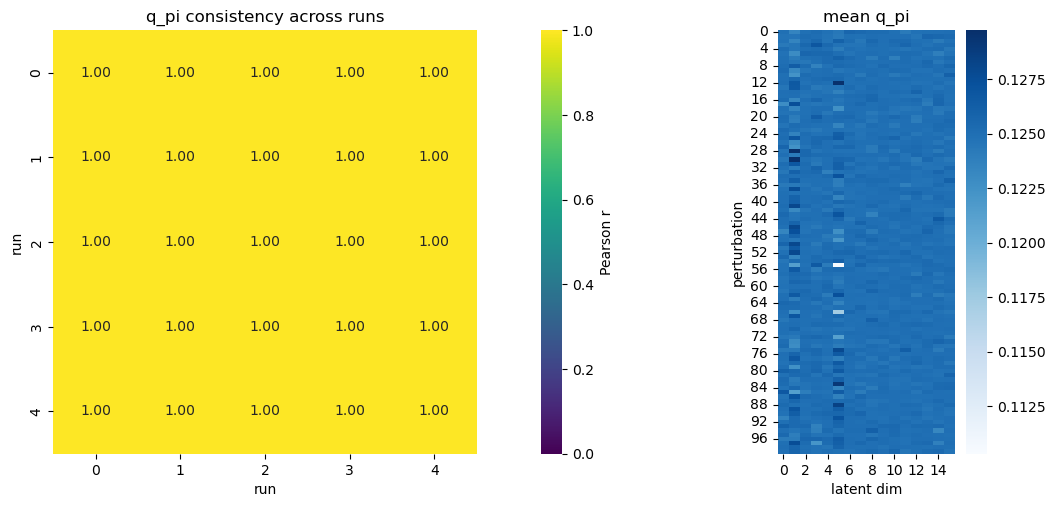

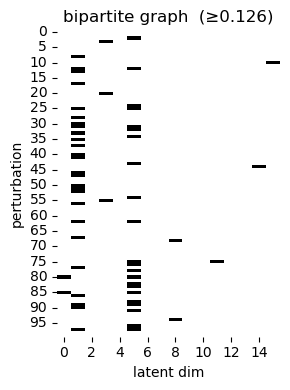

In [26]:
Pcorr, Q_mean, Q_bin = compare_and_plot_pi(models, thresh=0.126)

In [98]:
from utils import *

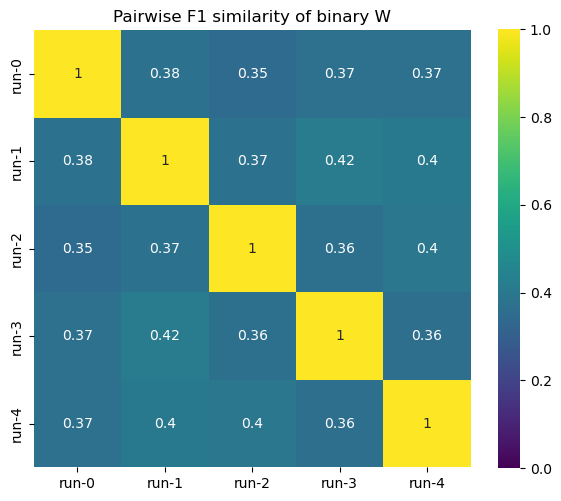

Mean f1 = 0.378 ± 0.020


In [ ]:
compare_W_runs_binary(, align=False)

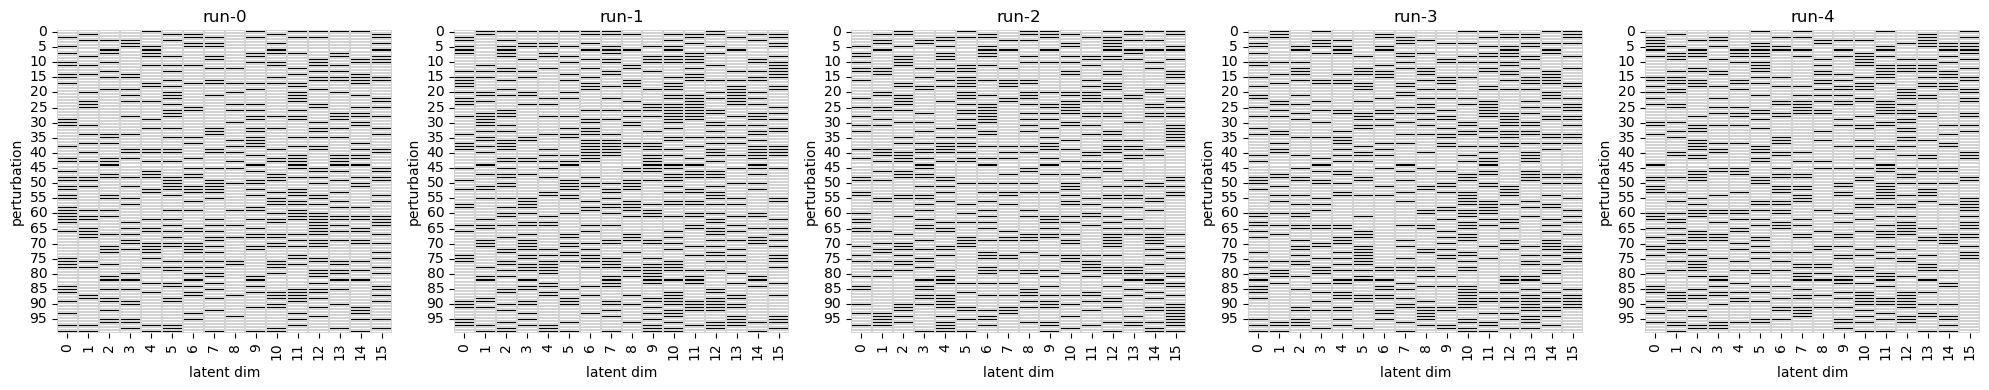

In [100]:
plot_binary_Ws(Ws)